## Assignment-20 Recurrent Neural Network(RNN)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### Load the dataset

In [6]:
df = pd.read_csv(r'Data\monthly_milk_production.csv')
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


##### Data Preprocessing

In [7]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
# Set Date as index
df.set_index('Date', inplace=True)

In [9]:
# Check dataset info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB
None


In [10]:
# Check missing values
print(df.isnull().sum())

Production    0
dtype: int64


#### Exploratory Data Analysis

##### Trend Visualization

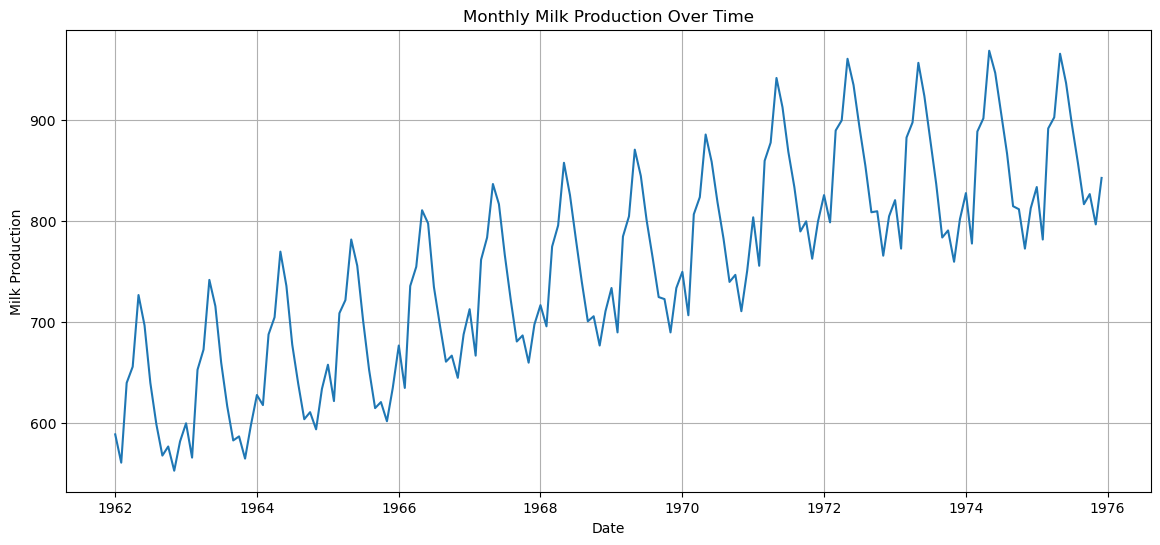

In [11]:
plt.figure(figsize=(14,6))
plt.plot(df['Production'])
plt.title("Monthly Milk Production Over Time")
plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.grid(True)
plt.show()

##### Seasonal Pattern

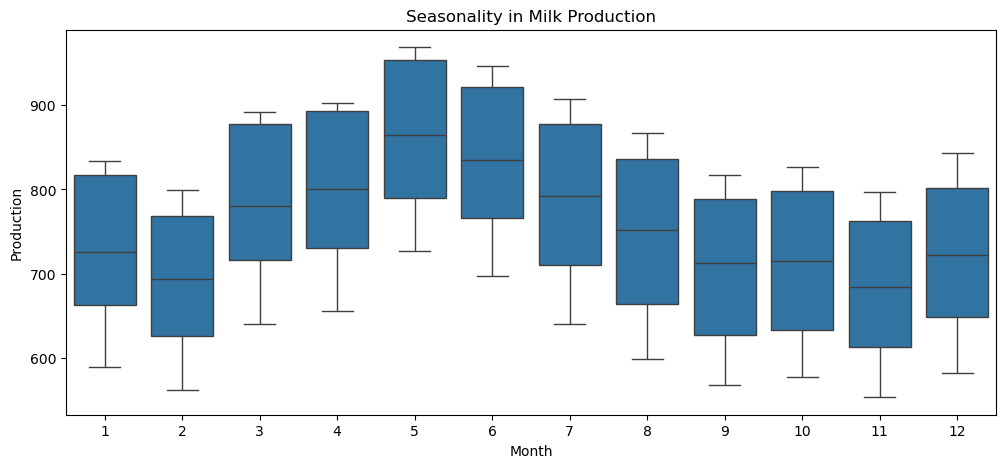

In [13]:
plt.figure(figsize=(12,5))
sns.boxplot(x=df.index.month, y=df['Production'])
plt.title("Seasonality in Milk Production")
plt.xlabel("Month")
plt.ylabel("Production")
plt.show()

##### ROlling Mean 

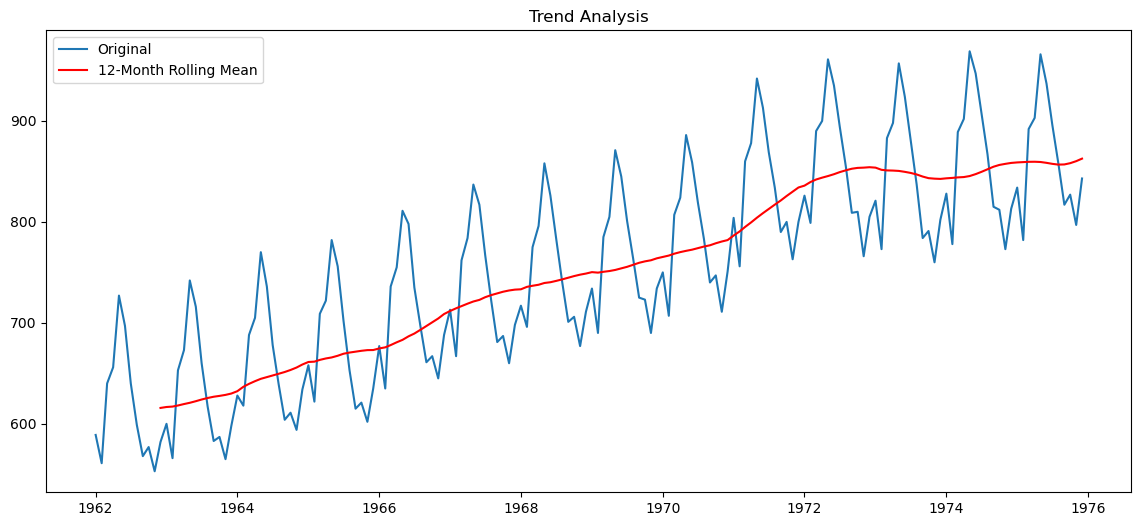

In [14]:
rolling_mean = df['Production'].rolling(window=12).mean()

plt.figure(figsize=(14,6))
plt.plot(df['Production'], label='Original')
plt.plot(rolling_mean, label='12-Month Rolling Mean', color='red')
plt.legend()
plt.title("Trend Analysis")
plt.show()

##### Normalize the data

In [17]:
from sklearn.preprocessing import MinMaxScaler

In [18]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[['Production']])

print(scaled_data[:5])

[[0.08653846]
 [0.01923077]
 [0.20913462]
 [0.24759615]
 [0.41826923]]


##### Time Series Sequences

In [19]:
def create_sequences(data, window_size):
    X, y = [], []

    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])

    return np.array(X), np.array(y)

window_size = 12

X, y = create_sequences(scaled_data, window_size)

print(X.shape)
print(y.shape)

(156, 12, 1)
(156, 1)


##### Train_Test_split

In [21]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(X_train.shape)
print(X_test.shape)

(124, 12, 1)
(32, 12, 1)


#### Build Deep Learning Models

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping

##### Early Stopping

In [23]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

#### Basic RNN Model

In [24]:
rnn_model = Sequential([
    SimpleRNN(64, activation='tanh', input_shape=(window_size,1)),
    Dense(1)
])

rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

C:\Users\javee\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 0.0274 - val_loss: 0.0501
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0061 - val_loss: 0.0031
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0025 - val_loss: 0.0064
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0020 - val_loss: 0.0122
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0013 - val_loss: 0.0052
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0013 - val_loss: 0.0053
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0011 - val_loss: 0.0081
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0011 - val_loss: 0.0092
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 9.7246e-04 - val_loss: 0.0065
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 9.1528e-04 - val_loss: 0.0101
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0012 - val_loss: 0.0086
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2

##### LSTM Model

In [25]:
lstm_model = Sequential([
    LSTM(64, activation='tanh', input_shape=(window_size,1)),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 0.1281 - val_loss: 0.0704
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0369 - val_loss: 0.0275
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0245 - val_loss: 0.0479
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0256 - val_loss: 0.0392
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0241 - val_loss: 0.0299
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0240 - val_loss: 0.0341
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0232 - val_loss: 0.0316
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0232 - val_loss: 0.0301
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0224 - val_loss: 0.0315
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0218 - val_loss: 0.0271


##### GRU Model

In [26]:
gru_model = Sequential([
    GRU(64, activation='tanh', input_shape=(window_size,1)),
    Dense(1)
])

gru_model.compile(
    optimizer='adam',
    loss='mse'
)

gru_history = gru_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 0.0971 - val_loss: 0.0506
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0303 - val_loss: 0.0318
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0247 - val_loss: 0.0548
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0230 - val_loss: 0.0394
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0223 - val_loss: 0.0359
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0211 - val_loss: 0.0378
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0205 - val_loss: 0.0343
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0207 - val_loss: 0.0329
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0198 - val_loss: 0.0376
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0179 - val_loss: 0.0262


##### Predictions

In [27]:
# RNN Predictions
rnn_pred = rnn_model.predict(X_test)

# LSTM Predictions
lstm_pred = lstm_model.predict(X_test)

# GRU Predictions
gru_pred = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step


##### Inverse Scaling

In [29]:
rnn_pred_actual = scaler.inverse_transform(rnn_pred)
lstm_pred_actual = scaler.inverse_transform(lstm_pred)
gru_pred_actual = scaler.inverse_transform(gru_pred)

y_test_actual = scaler.inverse_transform(y_test)

##### Evaluation Metrics

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [34]:
def evaluate_model(true, pred):

    mae = mean_absolute_error(true, pred)

    rmse = np.sqrt(mean_squared_error(true, pred))

    mape = np.mean(np.abs((true - pred) / true)) * 100

    return mae, rmse, mape

##### evaluate models

In [37]:
# RNN Metrics

rnn_mae, rnn_rmse, rnn_mape = evaluate_model(
    y_test_actual,
    rnn_pred_actual
)

print("RNN Metrics")
print("MAE:", rnn_mae)
print("RMSE:", rnn_rmse)
print("MAPE:", rnn_mape)


RNN Metrics
MAE: 20.809085845947255
RMSE: 24.386965891220328
MAPE: 2.4076394505046435


In [38]:
# LSTM Metrics

lstm_mae, lstm_rmse, lstm_mape = evaluate_model(
    y_test_actual,
    lstm_pred_actual
)

print("\nLSTM Metrics")
print("MAE:", lstm_mae)
print("RMSE:", lstm_rmse)
print("MAPE:", lstm_mape)


LSTM Metrics
MAE: 88.05527687072754
RMSE: 109.51673354928494
MAPE: 9.80925598022655


In [39]:
# GRU Metrics

gru_mae, gru_rmse, gru_mape = evaluate_model(
    y_test_actual,
    gru_pred_actual
)

print("\nGRU Metrics")
print("MAE:", gru_mae)
print("RMSE:", gru_rmse)
print("MAPE:", gru_mape)


GRU Metrics
MAE: 72.05610084533691
RMSE: 94.43270482805508
MAPE: 7.988156477269165


##### Comparing model performance

In [40]:
results = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'MAE': [rnn_mae, lstm_mae, gru_mae],
    'RMSE': [rnn_rmse, lstm_rmse, gru_rmse],
    'MAPE': [rnn_mape, lstm_mape, gru_mape]
})

print(results)

  Model        MAE        RMSE      MAPE
0   RNN  20.809086   24.386966  2.407639
1  LSTM  88.055277  109.516734  9.809256
2   GRU  72.056101   94.432705  7.988156


#### Plot Predictions vs Actual

##### RNN

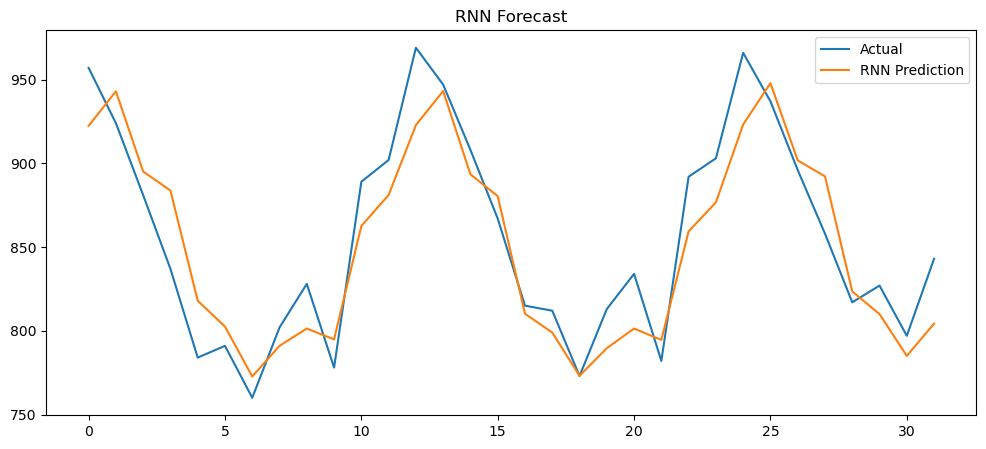

In [41]:
plt.figure(figsize=(12,5))
plt.plot(y_test_actual, label='Actual')
plt.plot(rnn_pred_actual, label='RNN Prediction')
plt.title("RNN Forecast")
plt.legend()
plt.show()

##### LSTM

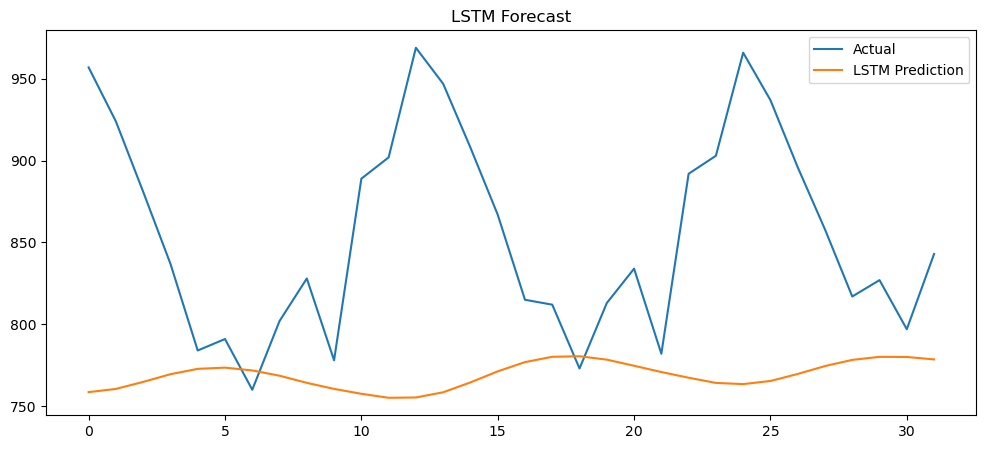

In [42]:
plt.figure(figsize=(12,5))
plt.plot(y_test_actual, label='Actual')
plt.plot(lstm_pred_actual, label='LSTM Prediction')
plt.title("LSTM Forecast")
plt.legend()
plt.show()

##### GRU

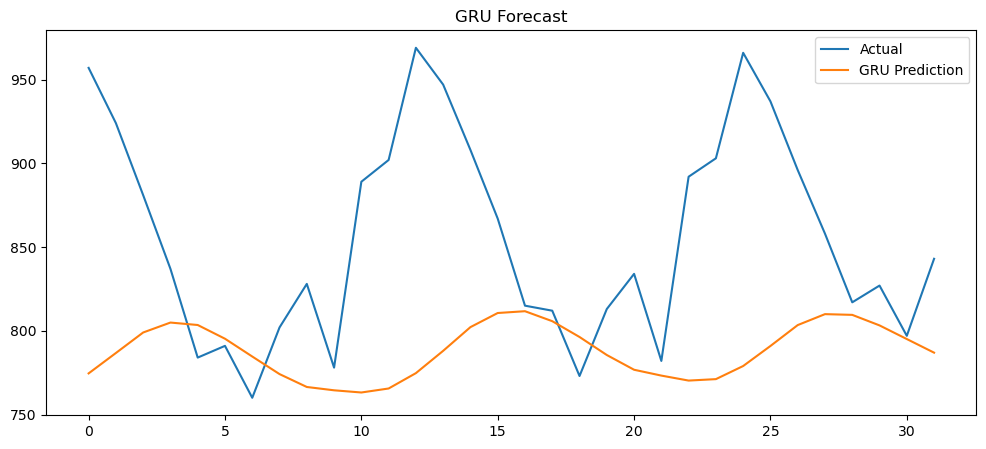

In [43]:
plt.figure(figsize=(12,5))
plt.plot(y_test_actual, label='Actual')
plt.plot(gru_pred_actual, label='GRU Prediction')
plt.title("GRU Forecast")
plt.legend()
plt.show()

#### Forecast milk production for the next 12 months

In [44]:
def forecast_future(model, data, steps, window_size):

    forecast = []

    current_batch = data[-window_size:].reshape(1, window_size, 1)

    for i in range(steps):

        pred = model.predict(current_batch)[0]

        forecast.append(pred)

        current_batch = np.append(
            current_batch[:,1:,:],
            [[pred]],
            axis=1
        )

    return np.array(forecast)

future_steps = 12

future_forecast = forecast_future(
    lstm_model,
    scaled_data,
    future_steps,
    window_size
)

future_forecast_actual = scaler.inverse_transform(future_forecast)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


C:\Users\javee\AppData\Local\Temp\ipykernel_22240\947992944.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


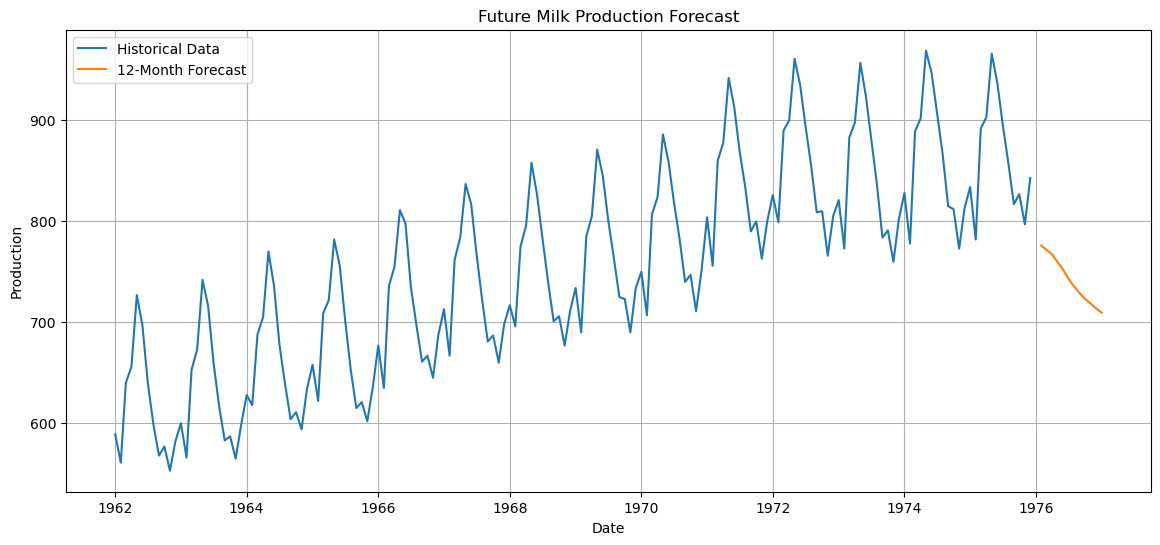

In [45]:
future_dates = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq='M'
)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast': future_forecast_actual.flatten()
})

plt.figure(figsize=(14,6))

plt.plot(df.index, df['Production'], label='Historical Data')

plt.plot(
    forecast_df['Date'],
    forecast_df['Forecast'],
    label='12-Month Forecast'
)

plt.title("Future Milk Production Forecast")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.grid(True)
plt.show()

#### Business Insights
##### Key Findings

Milk production shows strong seasonal patterns.

Deep learning models successfully capture long-term dependencies

LSTM and GRU generally perform better than basic RNN for time series forecasting.

Forecasting helps predict production fluctuations in advance.

#### Business Recommendations
Supply Chain Optimization

Forecasts help plan transportation and distribution efficiently.

Inventory Management

Cold storage and warehouse utilization can be optimized.

Workforce Planning

Labor requirements can be adjusted based on expected production.

Seasonal Planning

The company can prepare for peak and low production periods.

Strategic Decision Making

Long-term forecasts support expansion and investment decisions.

#### Conclusion
This project successfully developed and compared three deep learning models for milk production forecasting:

Basic RNN

LSTM

GRU

Among these, LSTM/GRU typically provide better forecasting performance due to their ability to remember long-term temporal patterns. These forecasts can significantly improve operational efficiency and business planning in the dairy industry.